# <font color='green'> <center> **Projet Epidémiologie Cabanes / Dechenais** </center>

## **Chargement des données :**

In [682]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import KNNImputer

%matplotlib inline

df_h1 = pd.read_csv('liver.csv')
df_h2 = pd.read_json('liver.json')


In [683]:
#df_h1

In [684]:
#df_h2

## **Analyse des jeux de données :**

In [685]:
#print(df_h1.info())
#df_h2.info()

#### **Remarque :**

- Total_Proteins est de type objet dans le df_h1 et de type float64 dans le df_h2

- ALT, ASP et Result de df_h1 sont appelés Alamine_Aminotransferase, Aspartate_Aminotransferase et Outcome dans df_h2

## **Visualisation graphique :**

In [686]:
#df_h2.hist(bins=50, figsize=(15, 10))
#plt.show()

In [687]:
#df_h1.hist(bins=50, figsize=(15, 10))
#plt.show()

## **Harmonisation de l'unité de la colonne Total_Proteins :**

In [688]:
def check_protein_format(protein_str, unite):
    return isinstance(protein_str, str) and protein_str.endswith(unite)

def extract_protein_value(protein_str):
    if check_protein_format(protein_str, 'mg/dL'):
        protein_float = float(str.split(protein_str, ' ')[0])
        return protein_float
    if check_protein_format(protein_str, 'g/dL'):
        protein_float = float(str.split(protein_str, ' ')[0])
        return protein_float * 1000
    if check_protein_format(protein_str, 'nan mg/dL'):
        return np.nan

df_h1['Total_Proteins'] = df_h1['Total_Proteins'].apply(extract_protein_value)
#df_h1.head(3)

## **Harmonisation de l'unité de Total_Bilirubin, Direct_Bilirubin :**

In [689]:
def harmonize_Total_Bilirubin(df):
    df['Total_Bilirubin'] = df['Total_Bilirubin']*10
    return df

df_h2 = harmonize_Total_Bilirubin(df_h2)
#df_h2.head(3)

In [690]:
def harmonize_Direct_Bilirubin(df):
    df['Direct_Bilirubin'] = df['Direct_Bilirubin']*10
    return df

df_h2 = harmonize_Direct_Bilirubin(df_h2)
#df_h2.head(3)

## **Renommer les colonnes du jeu de données df_h1 :**

In [691]:
df_h1.rename(columns={'Age': 'Age'
                    , 'Gender': 'Gender'
                    , 'Total_Bilirubin': 'Total_Bilirubin'
                    , 'Direct_Bilirubin': 'Direct_Bilirubin'
                    , 'Alkaline_Phosphotase': 'Alkaline_Phosphotase'
                    , 'ALT': 'Alamine_Aminotransferase'
                    , 'AST': 'Aspartate_Aminotransferase'
                    , 'Total_Protiens': 'Total_Protiens'
                    , 'Albumin': 'Albumin'
                    , 'Albumin_and_Globulin_Ratio': 'Albumin_and_Globulin_Ratio'
                    ,'Result': 'Outcome'
                     }, inplace=True)


#df_h1.head(3)

## **Concaténation des jeux de données :**

In [692]:
df_combined = pd.concat([df_h1, df_h2])
#df_combined

## **Retirer les doublons :**

In [693]:
df_combined.drop_duplicates(inplace=True)
#df_combined

## **Visualiser la distribution des données :**

In [694]:
#hist_df_combined = df_combined.hist(bins=50, figsize=(15, 10))

#### **Il y a des valeurs abérrantes dans certaines colonnes (Exemple : Total_Proteins avec beaucoup de 0).**

## **Gestion des Variables Catégorielles (OneHotEncoding, puis LabelEncoding) :**

j'ai utilisé ce site pour mettre 1 et 0 au lieu de True et False

https://stackoverflow.com/questions/77643432/why-is-pd-get-dummies-returning-boolean-values-instead-of-the-binaries-of-0-1


In [695]:
df_encoded = pd.get_dummies(data = df_combined, columns=['Gender'], dtype=int) 
df_encoded.head(3)

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome,Gender_Female,Gender_Male
0,41 to 60 yo,7.0,2.0,174.0,NaN,14,7800.0,4.2,NaN,2,0,1
1,41 to 60 yo,6.0,2.0,245.0,22.0,24,7100.0,3.4,0.9,1,0,1
2,21 to 40 yo,11.0,5.0,191.0,37.0,41,7700.0,4.3,NaN,2,0,1


In [696]:
def LabelEncoder2(df):
    if df['Age'] == '21 to 40 yo':
        return 1
    if df['Age'] == '41 to 60 yo':
        return 2
    if df['Age'] == '61 to 80 yo':
        return 3
    if df['Age'] == '>80 yo':
        return 4
    return 0

df_encoded_2 = df_encoded.copy()
df_encoded_2['Age'] = df_encoded_2.apply(LabelEncoder2, axis=1)

df_encoded_2.head(3)

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Outcome,Gender_Female,Gender_Male
0,2,7.0,2.0,174.0,NaN,14,7800.0,4.2,NaN,2,0,1
1,2,6.0,2.0,245.0,22.0,24,7100.0,3.4,0.9,1,0,1
2,1,11.0,5.0,191.0,37.0,41,7700.0,4.3,NaN,2,0,1


## **Complétion des valeurs manquantes :**

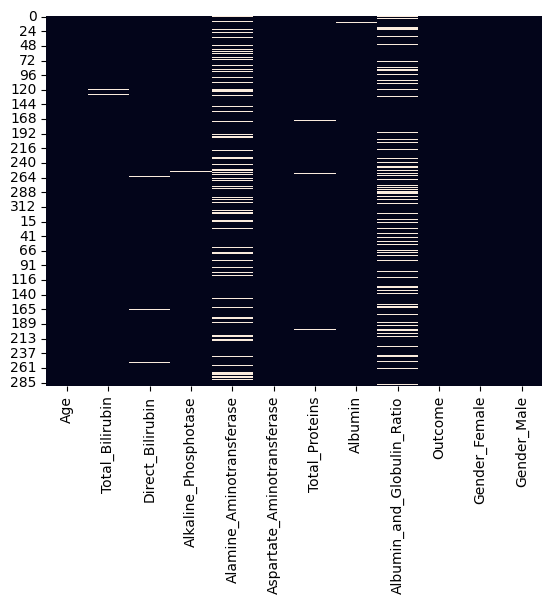

In [697]:
# Afficher un aperçu des valeurs manquantes (méthode isna())
import seaborn

na_columns = df_encoded_2.columns[df_encoded_2.isna().any()].tolist()
na_columns2 = seaborn.heatmap(df_encoded_2.isna(), cbar=False)

## **Imputation des valeurs par méthode K-Nearest Neighbour (KNN) :**

In [698]:
def data_imputation(df, cols = []):
    int_columns = df.select_dtypes(include='int').columns.tolist()
    imputer = KNNImputer(n_neighbors=5)
    df_imputed = df.copy()

    df_imputed[cols] = imputer.fit_transform(df_imputed[cols])

    df_imputed[int_columns] = df_imputed[int_columns].round(0).astype(int)

    return df_imputed

df_imputed = data_imputation(df_encoded_2, na_columns)

#df_imputed

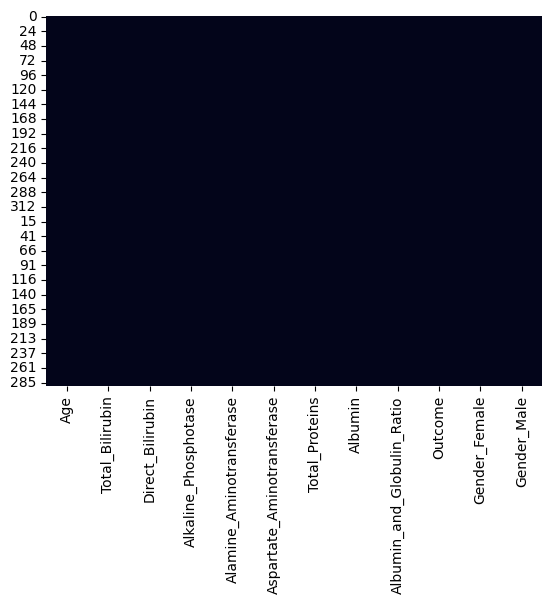

In [699]:
na_columns = df_imputed.columns[df_imputed.isna().any()].tolist()
na_columns2 = seaborn.heatmap(df_imputed.isna(), cbar=False)

## **Qualité des données après complétion des données manquantes et gestion du déséquilibre de classe :**

In [700]:
def compare_stats(df1, df2):
    stats_diff = pd.DataFrame(index=df1.columns, columns=['Mean_Diff', 'Std_Diff'])
    
    stats_diff['Mean_Diff'] = ((df2.mean() - df1.mean()) / df1.mean()).abs()
    stats_diff['Std_Diff'] = ((df2.std() - df1.std()) / df1.std()).abs()
    
    return stats_diff

df_stats_comp_after_completion = compare_stats(df_encoded_2, df_imputed)


df_stats_comp_after_completion

,Mean_Diff,Std_Diff
Age,0.000000,0.000000
Total_Bilirubin,0.002792,0.003870
Direct_Bilirubin,0.002453,0.003529
Alkaline_Phosphotase,0.001439,0.003899
Alamine_Aminotransferase,0.032667,0.069563
Aspartate_Aminotransferase,0.000000,0.000000
Total_Proteins,0.002864,0.002988
Albumin,0.000175,0.002517
Albumin_and_Globulin_Ratio,0.005237,0.083362
Outcome,0.000000,0.000000
